**Aula 1 - Variáveis categóricas, dummies, concatenar dataframes e reescalar dados**

In [1]:
import pandas as pd

uri = 'https://raw.githubusercontent.com/alura-cursos/machine-learning-algoritmos-nao-supervisionados/master/movies.csv'
filmes = pd.read_csv(uri)
filmes.columns = ['filme_id', 'titulo', 'generos']
filmes.head()

,filme_id,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [2]:
# Realizando a separação dos gêneros listados em colunas com classificação binária
generos = filmes.generos.str.get_dummies()
dados_dos_filmes = pd.concat([filmes, generos], axis=1)
dados_dos_filmes.head()

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# Analisando quais gêneros são mais marcantes na classificação de cada filme
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
generos_escalados = scaler.fit_transform(generos)

generos_escalados.shape # verificar se houve perda de informações durante o processo de 'scale'

(9742, 20)

**Observação**: Nesta aula o instrutor diz que ao realizar o StandardScale, encontramos a categoria de maior relevância para cada um dos filmes.

Na realidade esta informação não é verdadeira, com as informações contidas no dataset não conseguimos afirmar qual gênero é mais relevante aos respectivos filmes.

Aplicar o StandardScale ou outra padronização nos dados, quando features apresentam escalas diferentes é uma boa pratica, pois alguns algoritmos como K-MEANS, PCA, SVM e outros... São afetados pela diferença de escala entre as features. Para exemplificar, imagine o mesmo problema em clusterização de filmes, porém analisando duas features, tempo e custo. O tempo geralmente varia de 90 a 180 minutos o custo na casa dos milhões de dólares, realizar a padronização faz com que esses valores tenham escalas relativamente próxima e não impacte negativamente seu algoritmo de ML.

Como os dados são binários o k-means deve até ser evitado, para esse caso a distancia Euclidiana não trás um significado real, visto que o espaço dimensional dos dados passa a ser discreto e sem uma origem natural. Para esse problema você poderia transformar os gêneros em dados categóricos e aplicar variações do k-means conhecida como k-modes, introduzidas no paper de Zhexue Huang (https://arxiv.org/ftp/cs/papers/0603/0603120.pdf).

**Aula 2 - Modelo com KMeans, seu funcionamento, centroides, visualização deles e classificação**



1.   Explicação visual do K-means: https://www.naftaliharris.com/blog/visualizing-k-means-clustering/
2.   Vídeo explicativo de aplicações do K-means: https://www.youtube.com/watch?v=yqIH4K9IEHQ
3.   Mais detalhes sobre as aplicações: https://dzone.com/articles/10-interesting-use-cases-for-the-k-means-algorithm

In [4]:
from sklearn.cluster import KMeans

In [5]:
modelo = KMeans(n_clusters=3)
modelo.fit(generos_escalados)
print(f'Grupos {modelo.labels_}') # esse método de print usa o f no começo ao invés de usar print('Grupos {}'.format(modelo.labels_))

Grupos [2 2 0 ... 0 2 0]


**Aula 3 - Centroides, redução dimensional com TSNE, scatterplot com seaborn e filtros nos DataFrames** 

In [6]:
# Impressão dos gêneros e dos 3 centroides (1 centroide para cada gênero de filme --> total de 60 valores) "fittados" pelos clusters no algoritmo KMeans
# Quando maior for o valor no cluster_centers_, mais próximo o grupo está daquele gênero de filmes e mais filmes do gênero estão nesse grupo
print(generos.columns)
print(modelo.cluster_centers_)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')
[[ 0.03718158 -0.3196422  -0.29638571 -0.2200747  -0.18224451  0.24905694
  -0.27491431  0.13342489  0.10242285 -0.18142594 -0.08959578 -0.10824969
  -0.11251862  0.02284971 -0.2201504   0.18958695 -0.19496239 -0.48661325
   0.06061937  0.02889227]
 [-0.05917995  0.34443011 -0.27144974 -0.23524466 -0.26177995 -0.56224645
   0.92116332 -0.21328016  0.1061589  -0.16428849  0.29531782  0.43675484
  -0.07303529 -0.17640903  0.67695946 -0.31627997  0.07241632  1.43369349
  -0.12320804 -0.04115187]
 [-0.05917995  0.76435296  1.62770407  1.26101069  1.14841702 -0.13846894
  -0.31462227 -0.21094231 -0.58170462  0.993449   -0.09492563 -0.23904634
   0.57124651  0.18145075 -0.1575278  -0.27916393  0.6803341  -0.25077064
 

In [7]:
# Criação do DF 
grupos = pd.DataFrame(modelo.cluster_centers_,
             columns=generos.columns)

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7f1ca2b28da0>,
      dtype=object)

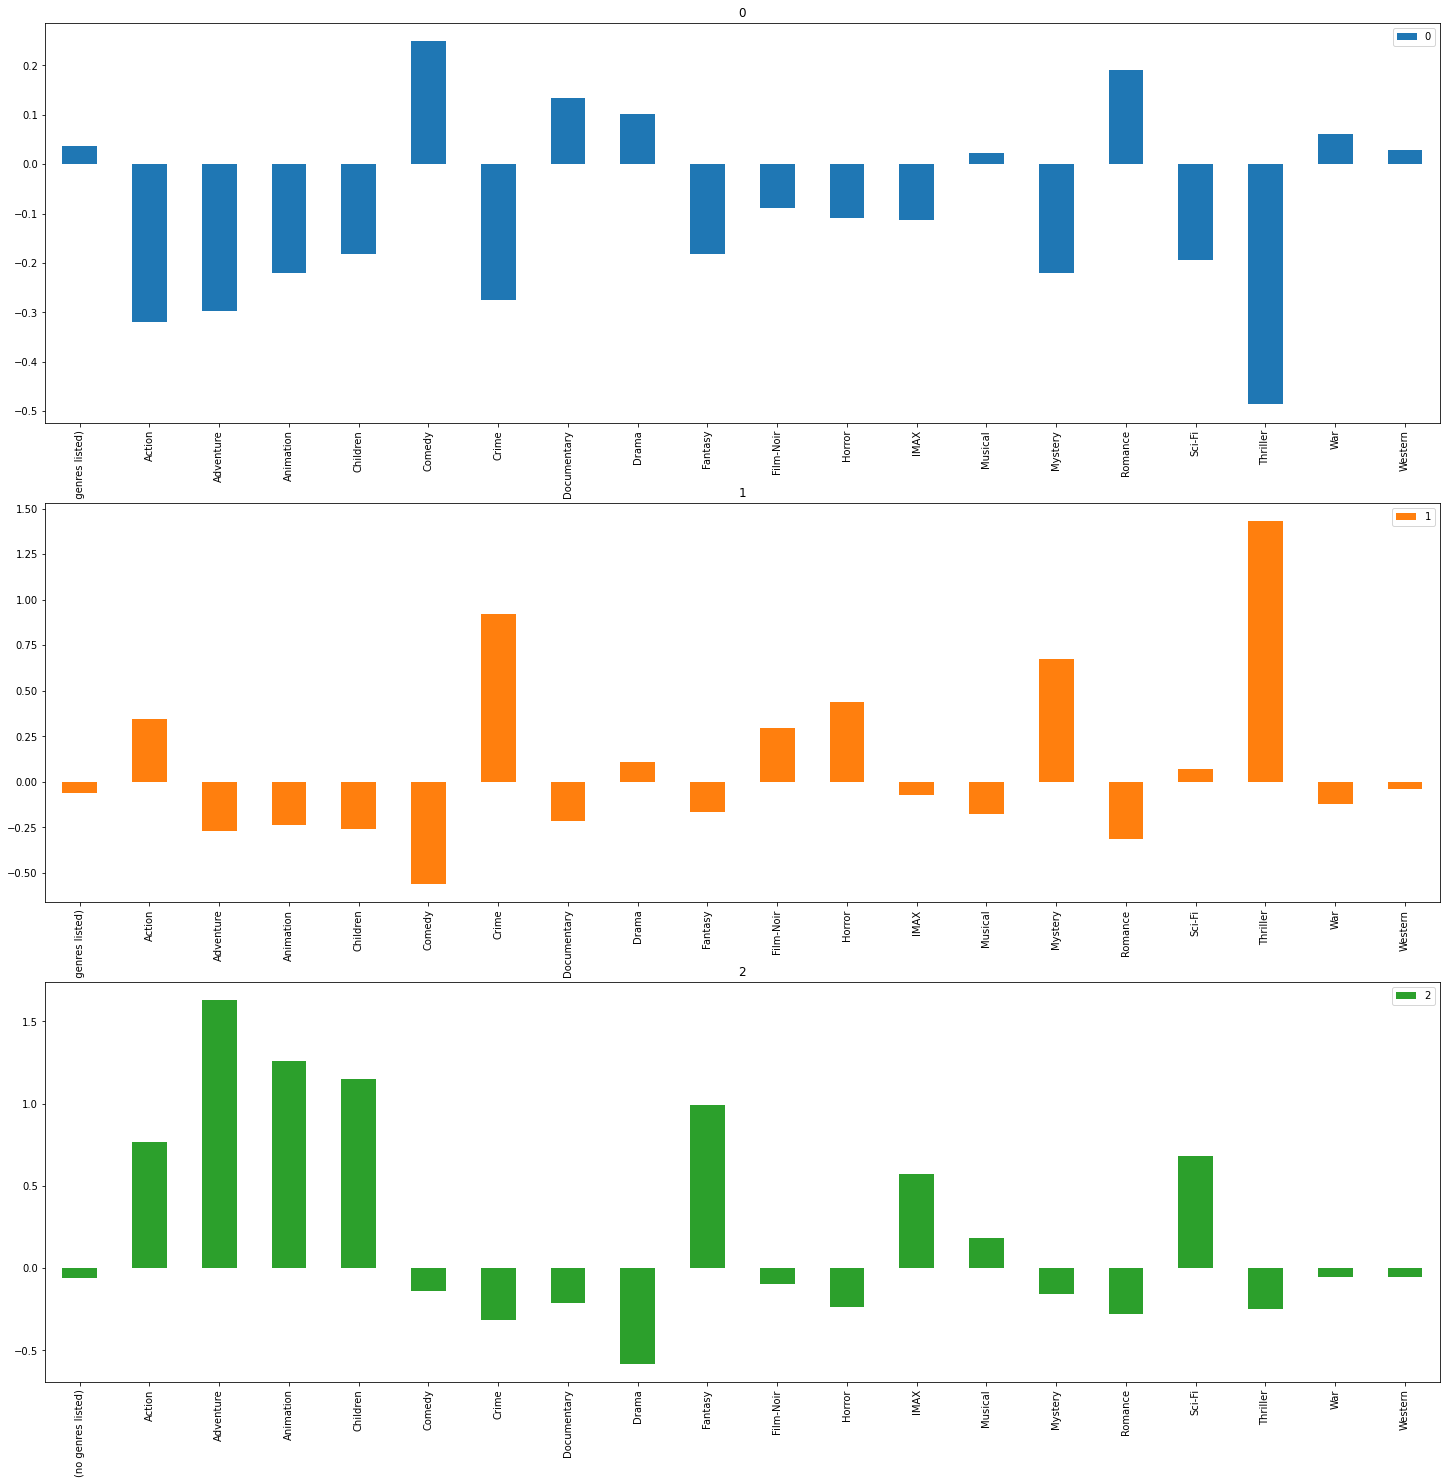

In [8]:
# Plotagem em gráfico de barras, feito em 3 subgráficos (1 para cada centroide) dividido por temas. Quanto maior por o valor de um gênero de filme,
# mais relacionado à esse gênero o grupo estará
# --> figsize(x,y) determina o tamanho da figura dentro da qual os gráficos serão plotados
# --> sharex = False diz que os gráficos não devem compartilhar a legenda do eixo x, ou seja, repetir a legenda em cada subplot para facilitar a visualização
grupos.transpose().plot.bar(subplots=True,
                figsize=(25,25),
                sharex=False)

1.   **Grupo 0:** associado à comédias ou comédia romântica
2.   **Grupo 1:** associado à filmes infantis ou animações
3.   **Grupo 2:** associado à filmes de terror, suspense ou drama


In [9]:
# Verificação se os filmes dentro de um grupo filtrado pelo cluster fazem sentido, de acordo com os gêneros mais influentes em cada cluster

grupo = 1 # 1 = filmes infantis/animações
filtro = modelo.labels_==grupo
dados_dos_filmes[filtro].sample(10)

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
6797,60684,Watchmen (2009),Action|Drama|Mystery|Sci-Fi|Thriller|IMAX,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,1,0,0
6300,48142,"Black Dahlia, The (2006)",Crime|Drama|Mystery|Thriller,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0
9700,185031,Alpha (2018),Adventure|Thriller,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
5850,32587,Sin City (2005),Action|Crime|Film-Noir|Mystery|Thriller,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0
5826,32213,Cube Zero (2004),Horror|Mystery|Sci-Fi|Thriller,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,0,0
7891,94919,Inhale (2010),Drama|Thriller,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3941,5543,"Swarm, The (1978)",Action|Horror|Sci-Fi,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
6428,51540,Zodiac (2007),Crime|Drama|Thriller,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
7558,85397,Red Riding Hood (2011),Fantasy|Horror|Mystery|Thriller,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0
311,353,"Crow, The (1994)",Action|Crime|Fantasy|Thriller,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0


**Construindo um gráfico de dispersão que mostra o posicionamento dos filmes em relação aos clusters usando a biblioteca sklearn**

In [10]:
from sklearn.datasets import make_blobs
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html

# --> uso de "_" na saída da função "make_blobs" para ignorar o output y que é um array com tamanho de n_samples
# --> n_samples: se for inteiro, significa número de pontos igualmente divididos entre os clusters, se for vetor significa que cada cluster vai ter um
#                número determinado de pontos por cluster, definido pelo array de input
# --> n_features: bidimensional, então esse parâmetro vale 2
# --> random_state = inicialização do seed randômico

dados, _ = make_blobs(n_samples=1000, n_features=2, random_state=7)
dados = pd.DataFrame(dados, columns=['coluna1','coluna2'])
dados.head()

,coluna1,coluna2
0,9.829632,0.763094
1,-9.723548,4.100788
2,10.403457,1.761671
3,-2.253417,4.660486
4,13.059859,-0.004112


In [11]:
# Realização de clusterização com 3 clusters
modelo1 = KMeans(n_clusters=3)
grupos = modelo1.fit_predict(dados)
centroides = modelo1.cluster_centers_

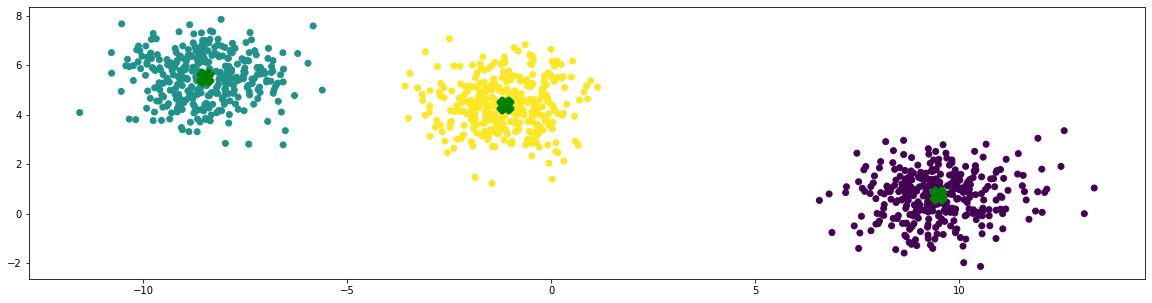

In [12]:
import matplotlib.pyplot as plt
# https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.figure.html

plt.figure(figsize=[20,5])
plt.scatter(dados.coluna1, dados.coluna2,
            c=grupos,
            cmap='viridis')

plt.scatter(centroides[:,0], centroides[:,1],
            marker='X', s=169, linewidth=5,
            color='g', zorder=8)

**Criando um modelo que consiga reduzir o número de dimensões do modelo original (n_clusters=20) para um modelo que seja representável em um gráfico bidimensional (2D) usando o algoritmo TSNE**

In [13]:
from sklearn.manifold import TSNE

In [14]:
# TSNE consegue reduzir modelos de muitas dimensões, com consequência da perda de informações 
tsne = TSNE()
visualizacao = tsne.fit_transform(generos_escalados)
visualizacao

array([[-41.76378 ,  27.780304],
       [ 66.15352 ,  24.194736],
       [ 33.65324 , -12.33575 ],
       ...,
       [-19.238873,  15.376943],
       [-48.20127 , -40.022167],
       [  9.291258, -11.96202 ]], dtype=float32)

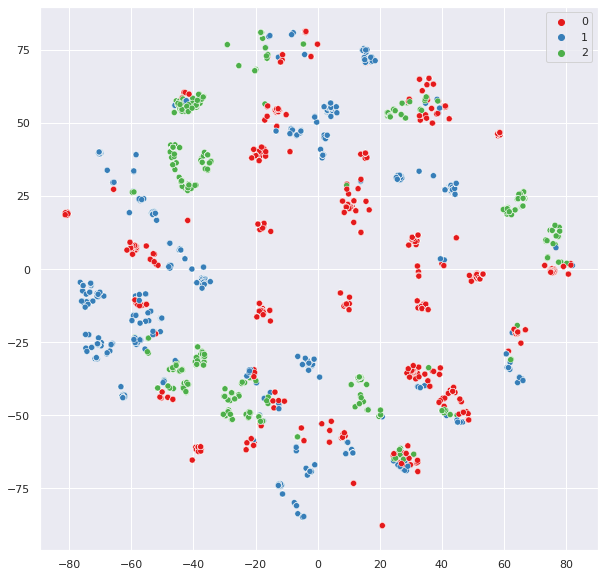

In [15]:
import seaborn as sns
# https://seaborn.pydata.org/

sns.set(rc={'figure.figsize': (10,10)})

sns.scatterplot(x=visualizacao[:,0],
                y=visualizacao[:,1],
                hue=modelo.labels_,
                palette=sns.color_palette('Set1', 3))

**Aula 4 - Seleção da quantidade de clusters e elbow method**

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7f1c9f0133c8>,
      dtype=object)

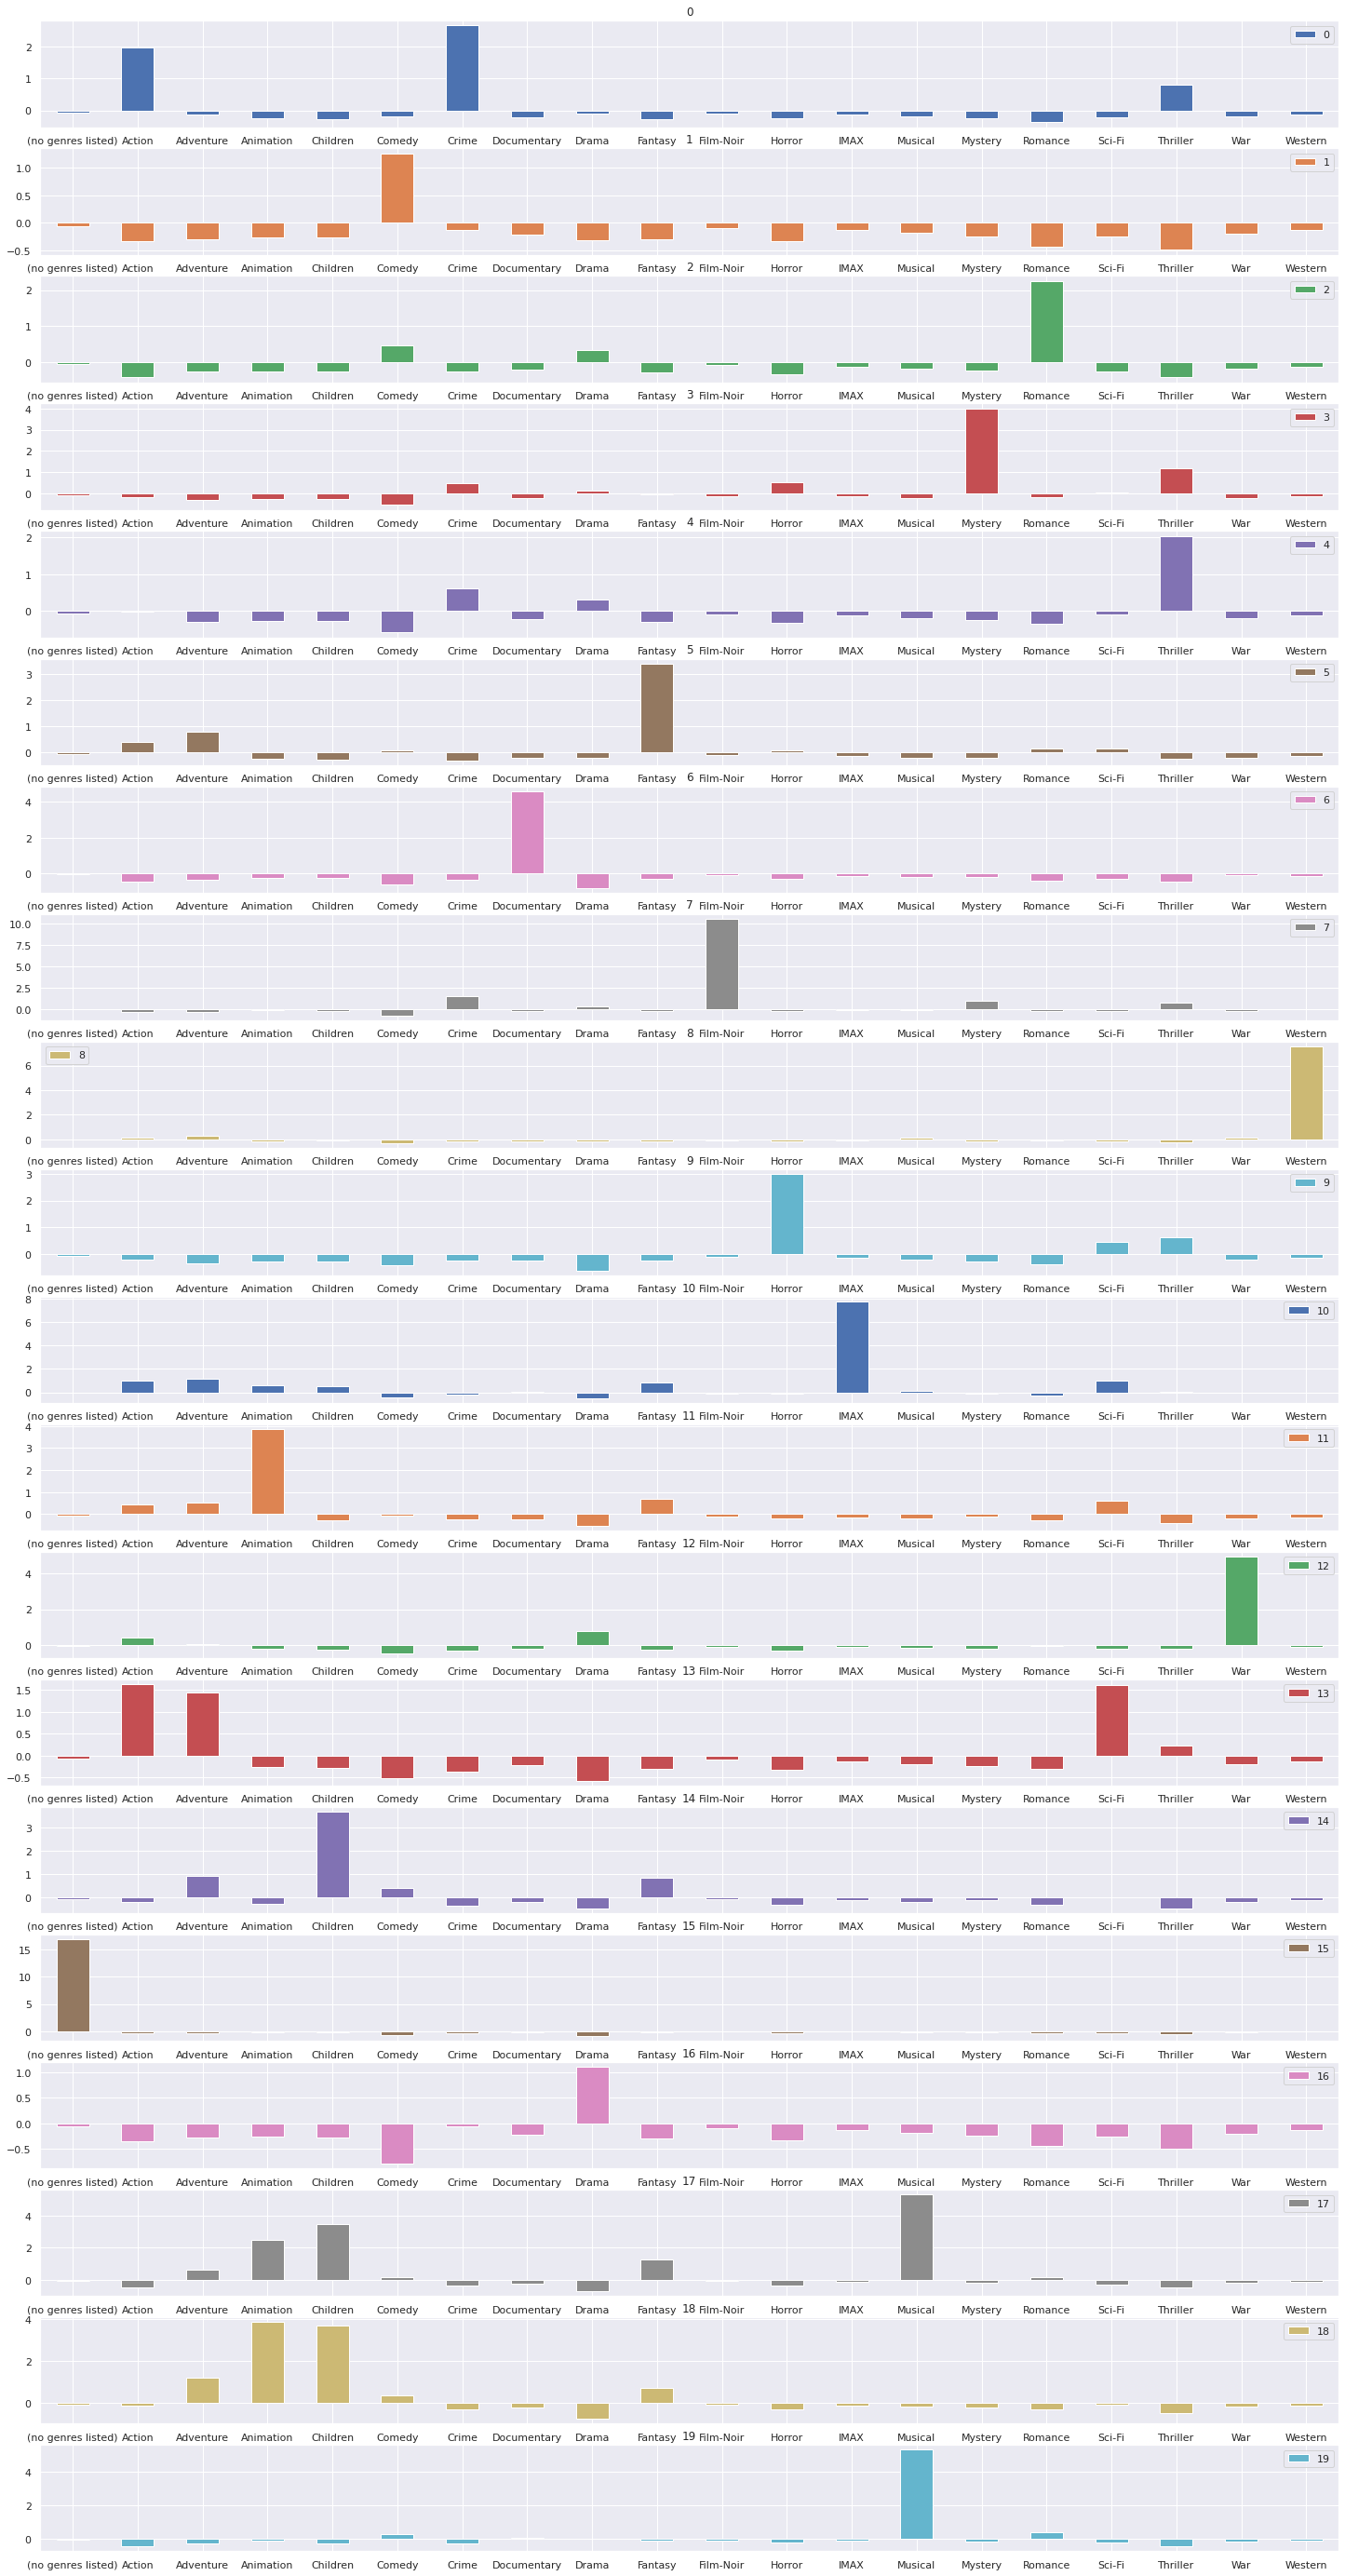

In [16]:
modelo = KMeans(n_clusters=20)

modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [17]:
# Verificação se os filmes dentro de um grupo filtrado pelo cluster fazem sentido, de acordo com os gêneros mais influentes em cada cluster

grupo = 8 # 1 = filmes de guerra
filtro = modelo.labels_==grupo
dados_dos_filmes[filtro].sample(10)

,filme_id,titulo,generos,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
2610,3494,True Grit (1969),Adventure|Drama|Western,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
5049,7894,"Duck, You Sucker (1971)",Action|Western,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4377,6412,Destry Rides Again (1939),Comedy|Western,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1002,1304,Butch Cassidy and the Sundance Kid (1969),Action|Western,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4517,6691,Dust (2001),Drama|Western,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
6355,49389,The Great Train Robbery (1903),Crime|Western,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
2517,3365,"Searchers, The (1956)",Drama|Western,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4651,6950,"Missing, The (2003)",Adventure|Thriller|Western,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3828,5372,Calamity Jane (1953),Musical|Western,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
6122,43419,Bandidas (2006),Action|Comedy|Crime|Western,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1


Como selecionar a quantidade adequada de clusters (menor número possível) para o problema? 
- Se utilizarmos menos parâmetros que o necessário -> Elementos que não deveriam ficar em um mesmo grupo acabam ficando juntos
- Se utilizarmos mais parâmetros que o necessário -> Criamos mais grupos do que o necessário para classificar todos os elementos. Nesse caso, elementos que deveriam ficar juntos acabam ficando separados devido a quantidade de possibilidades de grupos existentes.

Possível solução --> Analisar o erro do ajuste em função da quantidade de clusers através do elbow method, ou seja, a partir do gráfico, buscar o ponto onde há quebra da linha de tendência de redução do erro com aumento do n° de clusters

In [18]:
def kmeans(numero_de_clusters, generos):
  modelo = KMeans(n_clusters=numero_de_clusters)
  modelo.fit(generos)
  return [numero_de_clusters, modelo.inertia_] 

1.   KMeans utiliza o erro médio aboluto (MAE - Mean Absolute Error) (https://en.wikipedia.org/wiki/Mean_absolute_error)
2.   Para penalizar os pontos que ficam longe do centroide, pode-se usar o erro quadrático médio (MSE - Mean Squarred Error) (https://pt.wikipedia.org/wiki/Erro_quadr%C3%A1tico_m%C3%A9dio)




In [19]:
kmeans(20,generos_escalados)

[20, 55448.28100141482]

In [20]:
kmeans(3,generos_escalados)

[3, 169724.25051404713]

In [21]:
resultado = [kmeans(numero_de_grupos, generos_escalados) for numero_de_grupos in range(1,41)]
resultado 

[[1, 194840.0],
 [2, 179664.9990790031],
 [3, 166353.61004897274],
 [4, 156196.05544056706],
 [5, 145775.59698550068],
 [6, 137491.3293693164],
 [7, 126950.87246961397],
 [8, 118391.3273001641],
 [9, 111480.67921818365],
 [10, 104238.25935787591],
 [11, 94056.84756081736],
 [12, 85847.94873215978],
 [13, 81427.73450613924],
 [14, 73796.53110194627],
 [15, 69362.64869597237],
 [16, 63405.506891993595],
 [17, 60420.03072316604],
 [18, 59512.33909177106],
 [19, 57293.20697900973],
 [20, 55694.70229073282],
 [21, 53551.34919641558],
 [22, 52767.17842586188],
 [23, 49844.03166769131],
 [24, 49247.62187365369],
 [25, 47156.93340881005],
 [26, 46626.47849583563],
 [27, 46004.24886158141],
 [28, 45192.11604600185],
 [29, 44012.451508353486],
 [30, 42789.042949563314],
 [31, 41858.76613285228],
 [32, 41353.84044342967],
 [33, 40081.972874128696],
 [34, 39373.38443818183],
 [35, 38963.657101383],
 [36, 38656.60978491065],
 [37, 37570.80852295681],
 [38, 35915.87257873461],
 [39, 35330.2452679329

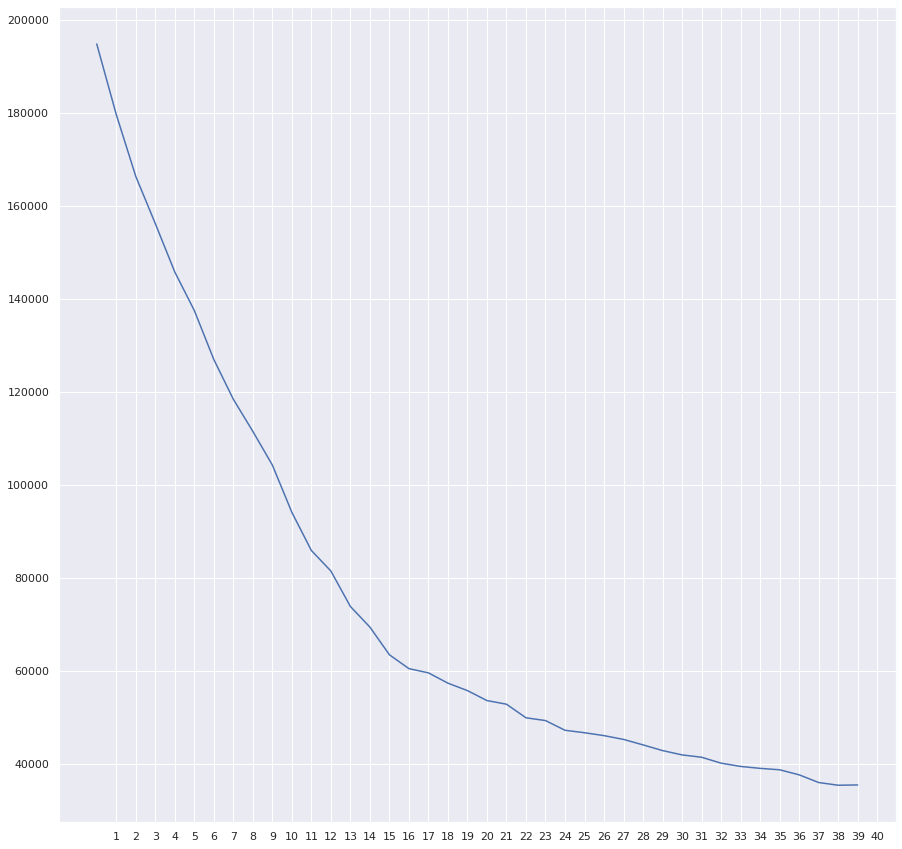

In [22]:
resultado = pd.DataFrame(resultado,
                         columns=['grupos','erro'])
resultado['erro'].plot(xticks=resultado.grupos,
                       figsize=(15,15))

Nesse gráfico não fica claro o posicionamento da quebra da curva como no gráfico do vídeo, então vou continuar com o código igual foi feito na video aula com 17 clusters.

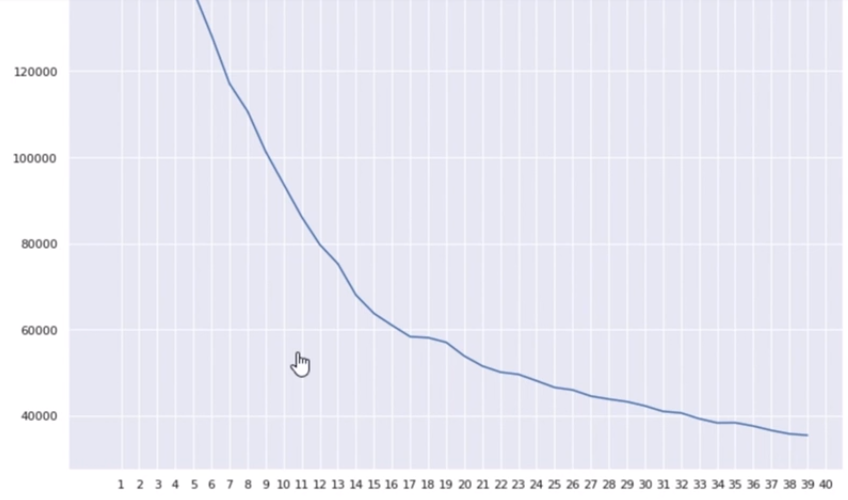

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7f1c9e2b7a58>,
      dtype=object)

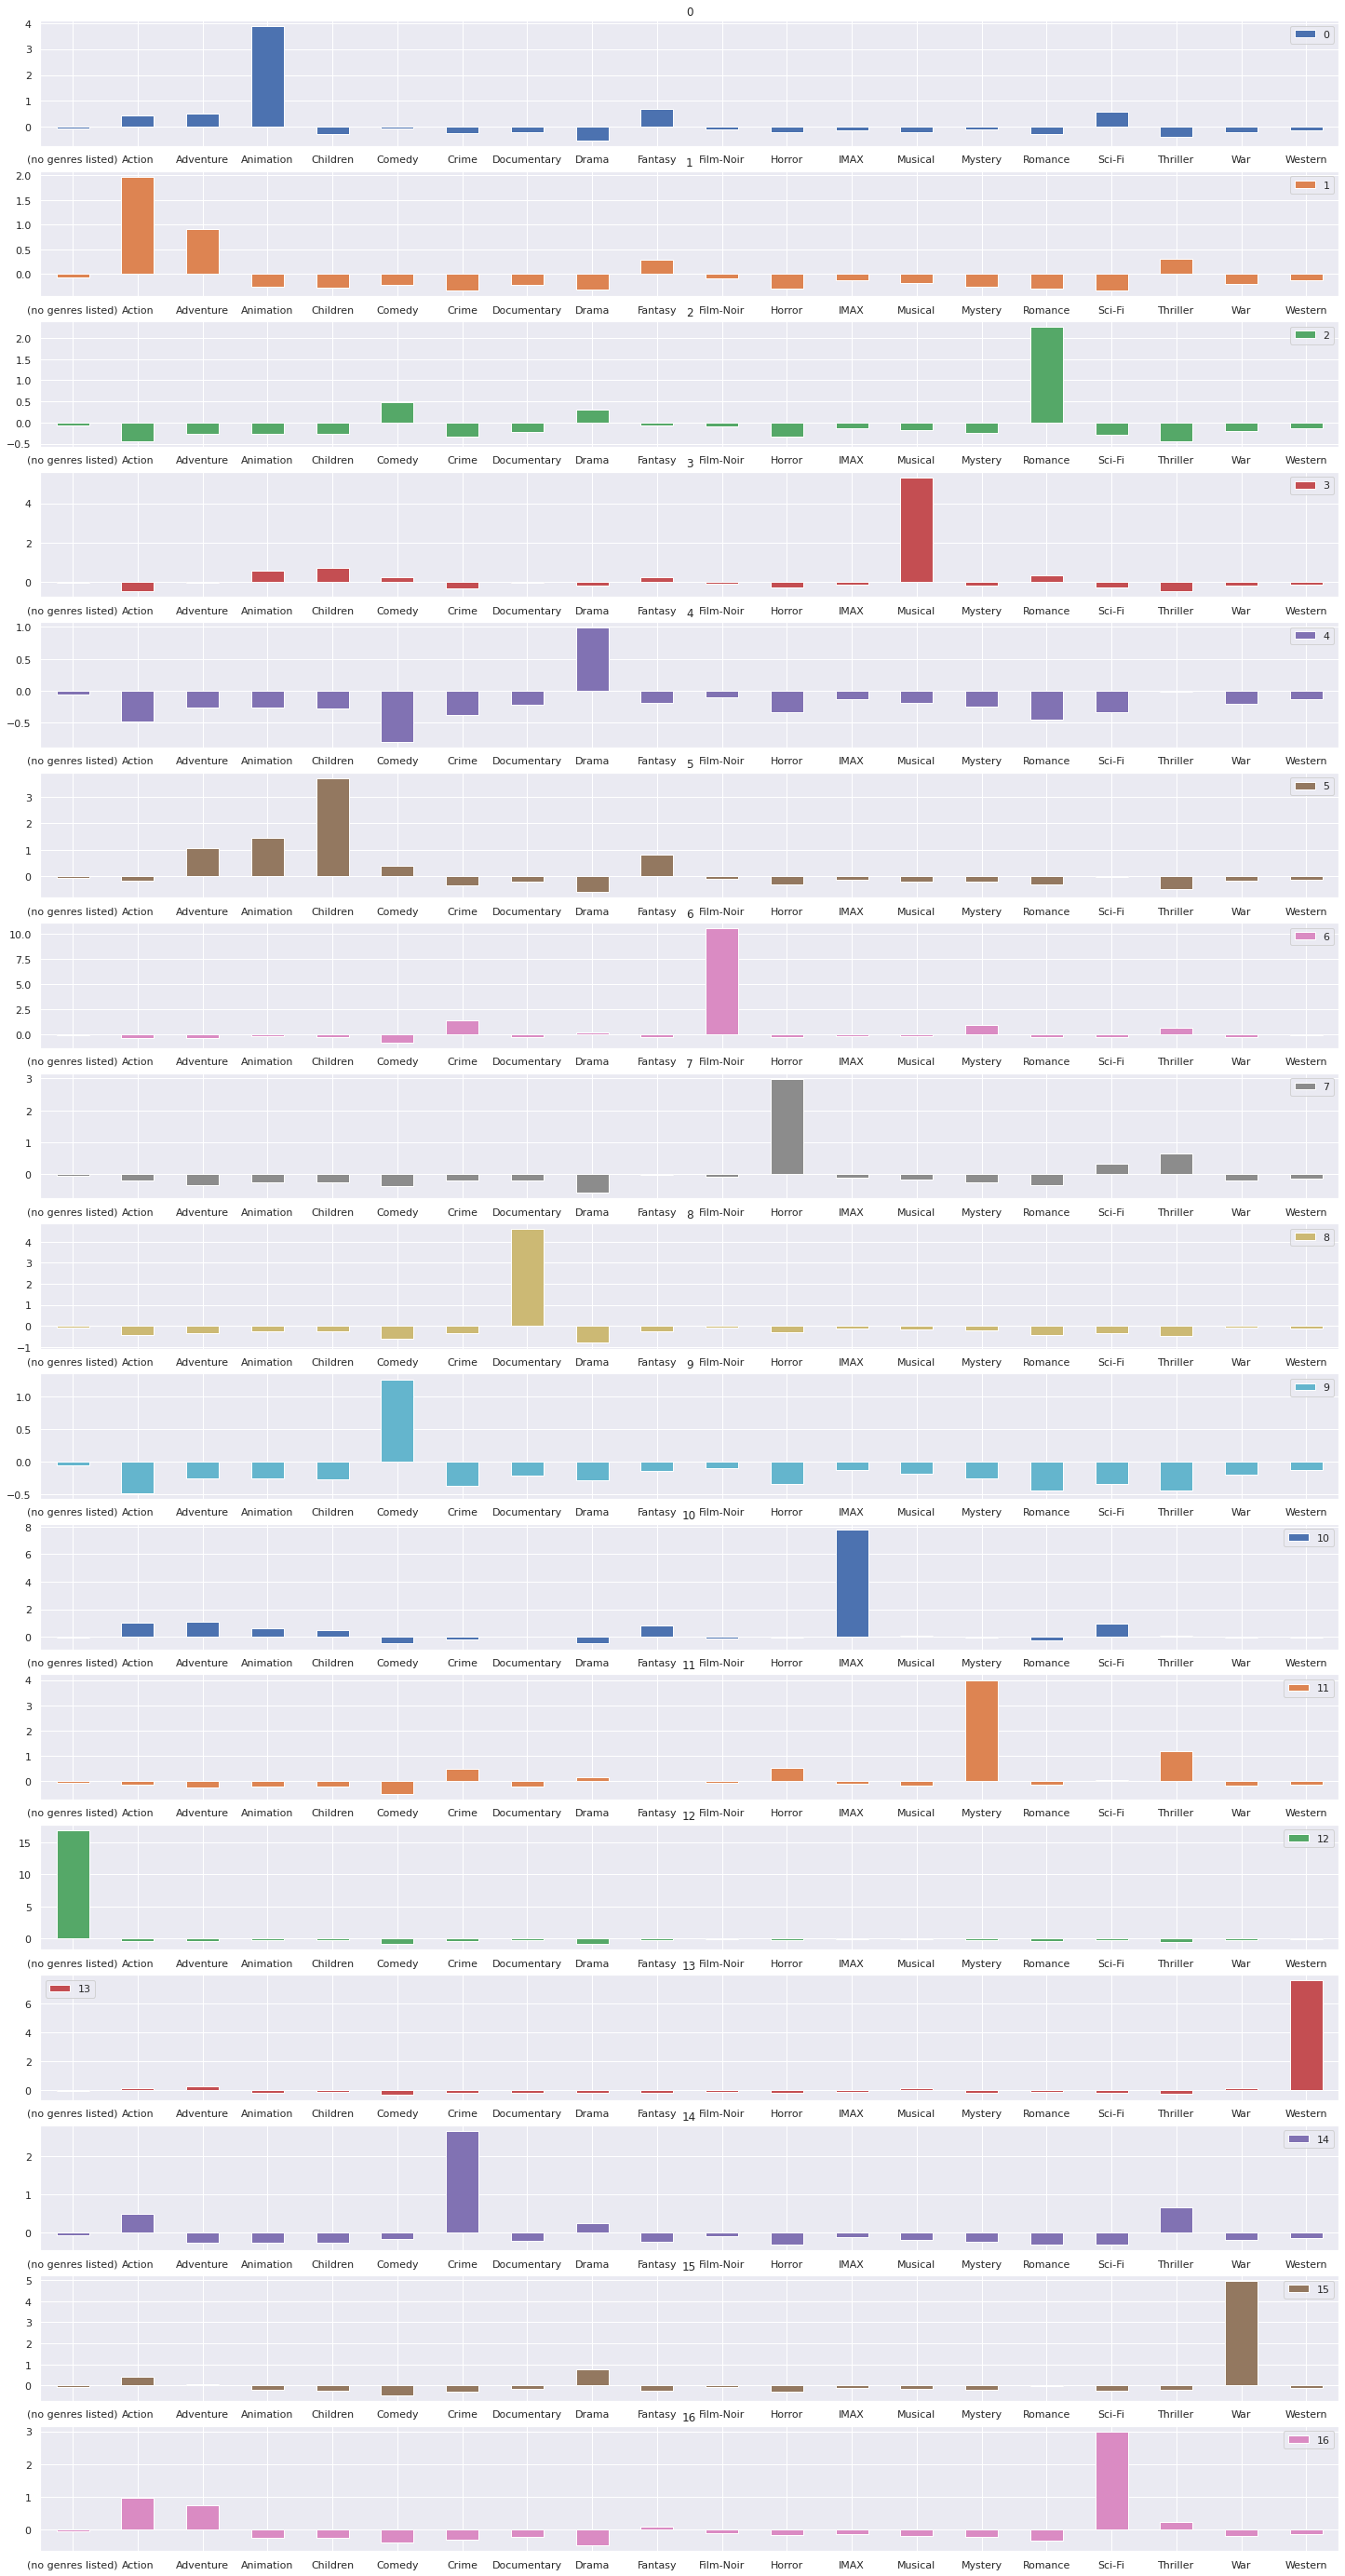

In [23]:
# Criando o novo modelo com n_clusters = 17
modelo = KMeans(n_clusters=17)
modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

**Aula 5 - Agrupamento hierárquico (sklearn Agglomerative Clustering) vs. Agrupamento particionado (KMeans)**

Agrupamento que tenta definir uma hierarquia entre os dados, ou seja, criando hierarquia compondo uma estrutura semelhante a de uma árvore (nosso conjunto de dados se bifurca nos subconjuntos romance e terror, e romance se bifurca nos subconjuntos drama e comédia.), calculando a chamada "matriz de distância" dos nossos dados, definindo uma distância entre cada um dos grupos.


1.   *Top down*: parte de um conjunto maior para verificar quais são os subgrupos mais distantes ou mais próximos
2.   *Bottom up*: parte dos subgrupos para um conjunto maior



In [24]:
from sklearn.cluster import AgglomerativeClustering
modelo = AgglomerativeClustering(n_clusters=17)
grupos = modelo.fit_predict(generos_escalados)
grupos

array([ 5, 14, 13, ...,  2,  5,  3])

In [25]:
tsne = TSNE()
visualizacao = tsne.fit_transform(generos_escalados)
visualizacao

array([[ -4.6668234, -59.41834  ],
       [-22.337029 ,  64.43328  ],
       [ 29.680658 , -12.996658 ],
       ...,
       [ 21.680859 ,  15.852908 ],
       [-21.108541 ,  38.97967  ],
       [-12.175607 ,  -8.769804 ]], dtype=float32)

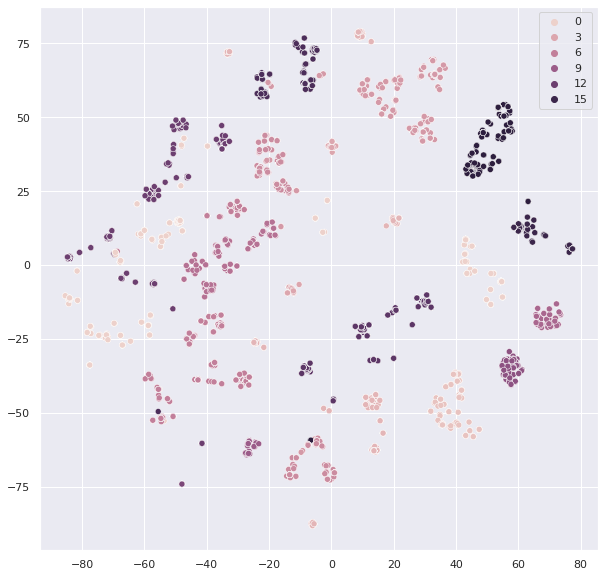

In [26]:
sns.scatterplot(x=visualizacao[:, 0],
               y=visualizacao[:, 1],
               hue=grupos)

Criação de um "Dendograma" (https://operdata.com.br/blog/analise-de-cluster/)

Infos. clusterização hierárquica: https://www.saedsayad.com/clustering_hierarchical.htm

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7f1c9d84c3c8>,
      dtype=object)

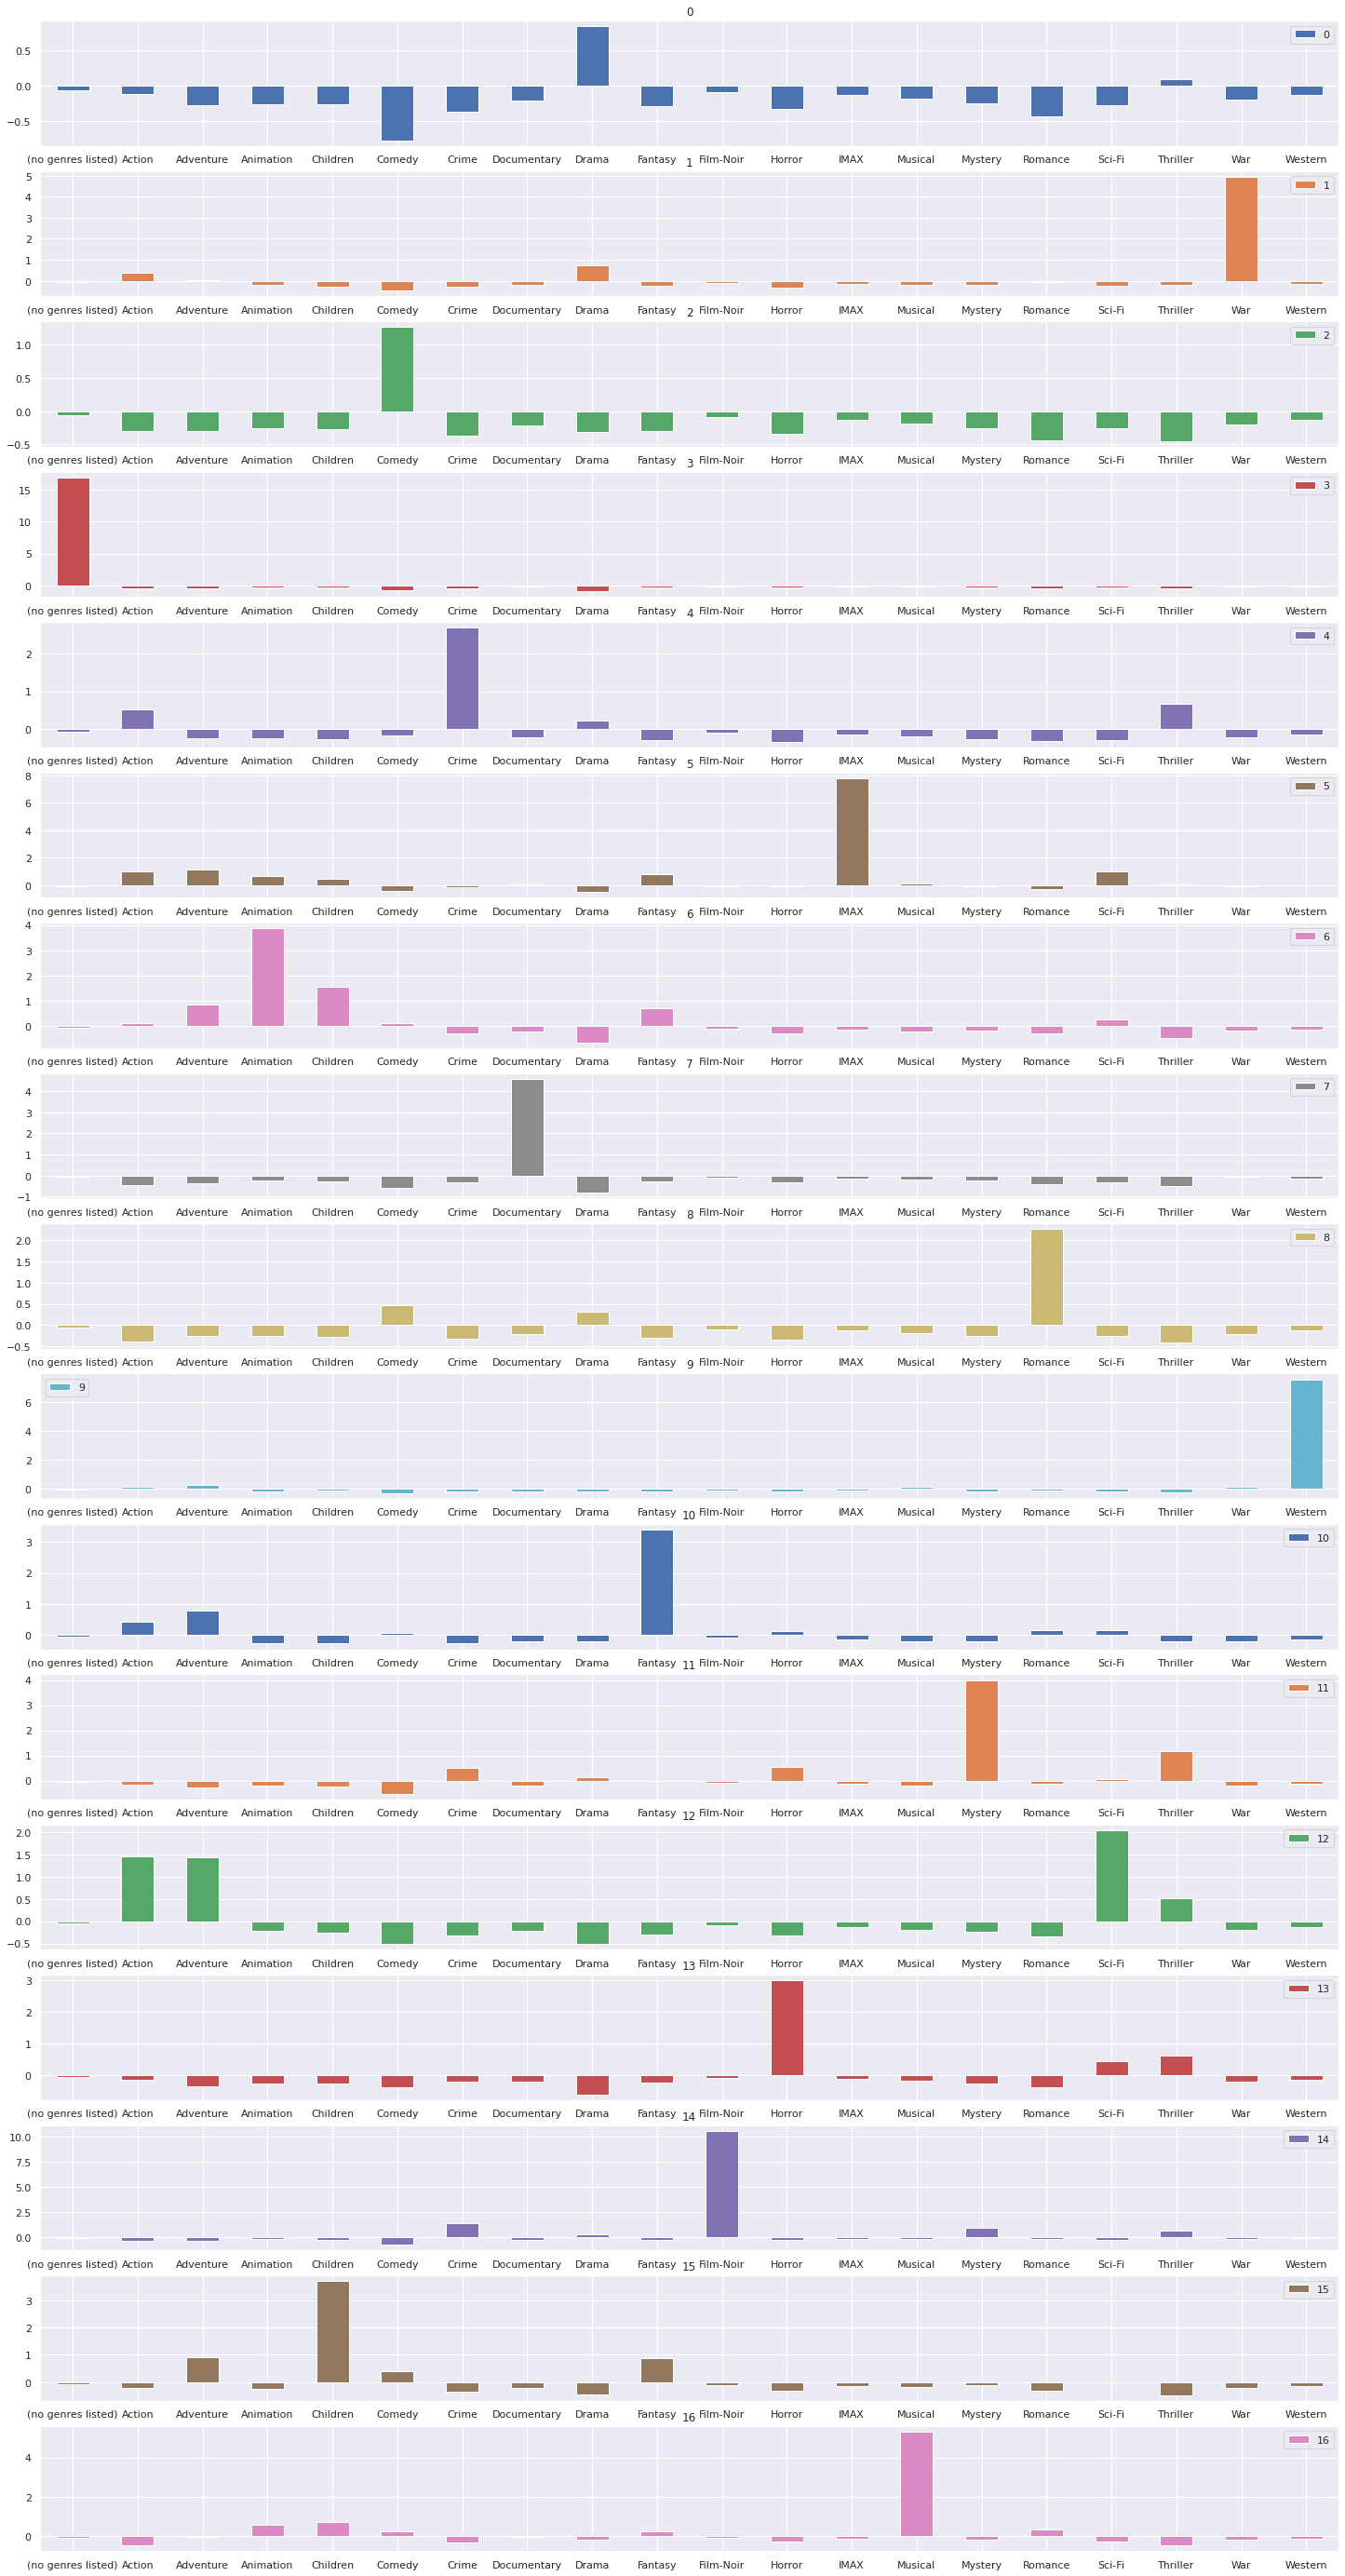

In [28]:
modelo = KMeans(n_clusters=17)
modelo.fit(generos_escalados)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=generos.columns)

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [29]:
matriz_de_distancia = linkage(grupos)
matriz_de_distancia

array([[ 0.        ,  2.        ,  2.41578714,  2.        ],
       [ 8.        , 17.        ,  2.88570874,  3.        ],
       [ 4.        , 18.        ,  3.28545738,  4.        ],
       [12.        , 19.        ,  3.59196849,  5.        ],
       [13.        , 20.        ,  3.76551611,  6.        ],
       [10.        , 21.        ,  4.18363754,  7.        ],
       [15.        , 22.        ,  4.40515421,  8.        ],
       [11.        , 23.        ,  4.64366741,  9.        ],
       [ 6.        , 24.        ,  4.67841865, 10.        ],
       [ 7.        , 25.        ,  5.14008351, 11.        ],
       [ 1.        , 26.        ,  5.22232064, 12.        ],
       [16.        , 27.        ,  5.82711776, 13.        ],
       [ 9.        , 28.        ,  7.84392478, 14.        ],
       [ 5.        , 29.        ,  8.18825233, 15.        ],
       [14.        , 30.        , 10.81560737, 16.        ],
       [ 3.        , 31.        , 17.06049421, 17.        ]])

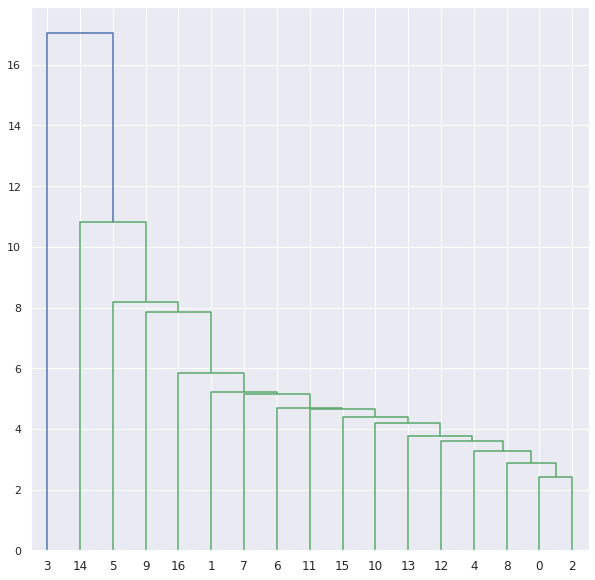

In [30]:
dendrograma = dendrogram(matriz_de_distancia)

**Agrupamento por densidade vs. Particionado + Hierárquico**

Quando não sabemos os números de clusters, a abordagem de agrupamento por densidade pode tentar resolver o probblema usando a classe DBSCAN

https://www.geeksforgeeks.org/dbscan-clustering-in-ml-density-based-clustering/

https://towardsdatascience.com/dbscan-clustering-explained-97556a2ad556


In [31]:
dados, _ = make_blobs(n_samples=2000, n_features=3, centers=6, random_state=7)
dados = pd.DataFrame(dados, columns=['coluna1','coluna2','coluna3'])

In [32]:
def dbscan(X, eps, min_samples):
    ss = StandardScaler()
    X = ss.fit_transform(X)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(X)
    y_pred = db.fit_predict(X)
    plt.scatter(X[:,0], X[:,1],c=y_pred, cmap='viridis')
    plt.title("DBSCAN")

In [33]:
dbscan(dados, 0.25, 20)

NameError: ignored